# PTB-XL Multi-Label ECG Classification — Model & Ablation Study

**Course:** CS-598 Deep Learning for Healthcare  
**Dataset:** PTB-XL (PhysioNet / CinC Challenge 2020, v1.0.2)  
**Models:** ResNet-18 (control), SE-ResNet-50, Lambda-ResNet-18, BiLSTM (Nonaka & Seita 2021)

---

## Background & Motivation

PTB-XL is the largest publicly available clinical 12-lead ECG dataset, containing
21,837 recordings from 18,885 patients at 500 Hz (≈ 10 s per recording).
Each recording is annotated with one or more *SNOMED-CT* codes.

We frame ECG diagnosis as **multi-label classification**: given a signal
$X \in \mathbb{R}^{C \times T}$ ($C=12$ leads, $T$ time-steps), predict a
binary label vector $y \in \{0,1\}^K$ for $K$ diagnostic classes.

### Mathematical Framing

| Symbol | Meaning |
|--------|---------|
| $C = 12$ | ECG leads |
| $T$ | Time-steps: **1 000** at 100 Hz or **5 000** at 500 Hz |
| $K$ | Label classes: **5** (superdiagnostic) or **27** (diagnostic) |
| $f_\theta$ | Model backbone (ResNet-18, SE-ResNet-50, Lambda-ResNet-18, or BiLSTM) |

**Forward pass:**
$$\hat{y} = \sigma\!\left(f_\theta(X)\,W^\top + b\right) \in [0,1]^K$$

**Training loss (Binary Cross-Entropy per label):**
$$\mathcal{L}_{\text{BCE}} = -\frac{1}{K}\sum_{k=1}^{K}\left[y_k\log\hat{y}_k + (1-y_k)\log(1-\hat{y}_k)\right]$$

**Evaluation — macro-averaged ROC-AUC:**
$$\overline{\text{AUC}} = \frac{1}{K}\sum_{k=1}^{K}\int_0^1 \text{TPR}_k(t)\,d\,\text{FPR}_k(t)$$

**Evaluation — macro-averaged F1 (threshold = 0.5):**
$$\overline{F_1} = \frac{1}{K}\sum_{k=1}^{K}\frac{2\,\text{TP}_k}{2\,\text{TP}_k + \text{FP}_k + \text{FN}_k}$$

---

## Ablation Design

We vary two axes simultaneously (as done in Strodthoff *et al.* 2020) and
compare **four model architectures** across a $2 \times 2$ task grid:

| Config | `label_type` | `sampling_rate` | $K$ | $T$ |
|--------|-------------|-----------------|-----|-----|
| **A** (baseline) | superdiagnostic | 100 Hz | 5 | 1 000 |
| **B** | superdiagnostic | 500 Hz | 5 | 5 000 |
| **C** | diagnostic | 100 Hz | 27 | 1 000 |
| **D** | diagnostic | 500 Hz | 27 | 5 000 |

Holding the hyper-parameters **constant** across all runs isolates the effect of:
(a) label granularity, (b) temporal resolution, and (c) model architecture.

**Hypotheses:**
* Finer label granularity (27 classes) is a harder task → lower absolute AUC.
* Higher temporal resolution (500 Hz) provides more information → higher AUC
  at the cost of increased input size and training time.
* **SE-ResNet-50** (CNN + channel attention) is expected to outperform the plain
  **ResNet-18** control by learning which channels to emphasise.
* **Lambda-ResNet-18** replaces SE attention with Lambda layers (content- and
  position-based linear attention), and may close or exceed SE-ResNet-50 performance
  while using fewer parameters.
* **BiLSTM** captures global temporal context but may underperform CNN variants on
  short-context morphological features; it is expected to be more competitive at
  500 Hz where longer sequences provide more temporal signal.

## 0. Environment Setup

Install dependencies if running on a fresh Colab runtime.

In [1]:
# Uncomment the lines below to install on Colab / a fresh environment
# !pip install pyhealth scipy wfdb --quiet

import sys
print(f'Python {sys.version}')

import torch
print(f'PyTorch {torch.__version__}  |  CUDA available: {torch.cuda.is_available()}')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Python 3.9.6 (default, Dec  2 2025, 07:27:58) 
[Clang 17.0.0 (clang-1700.6.3.2)]
PyTorch 2.8.0  |  CUDA available: False
Using device: cpu


In [2]:
import sys, pathlib
# Add the repo root so 'pyhealth' is importable from this notebook
_REPO_ROOT = str(pathlib.Path(__file__).resolve().parents[1]) if "__file__" in dir() else "/Users/anuragd/CS-598_HealthCareAssignment/DLH598_repo/PyHealth"
if _REPO_ROOT not in sys.path:
    sys.path.insert(0, _REPO_ROOT)
print(f"Repo root on path: {_REPO_ROOT}")


Repo root on path: /Users/anuragd/CS-598_HealthCareAssignment/DLH598_repo/PyHealth


## 1. Dataset Path

Point `PTBXL_ROOT` to the `training/ptb-xl/` sub-directory of the
PhysioNet Challenge 2020 download (v1.0.2).  
It should contain group sub-directories `g1/`, `g2/`, …, `g22/`, each
holding pairs of WFDB files (`.hea` header + `.mat` signal matrix).

```
training/ptb-xl/
  g1/
    HR00001.hea
    HR00001.mat
    ...
  g2/ ...
  ...
  g22/
```

In [3]:
import os
from pathlib import Path

# -----------------------------------------------------------------------
# PTB-XL data root — contains g1/…g22/ sub-dirs AND ptbxl_database.csv
# -----------------------------------------------------------------------
PTBXL_ROOT = str(
    Path("/Users/anuragd/CS-598_HealthCareAssignment/DLH_Project/classification-of-12-lead-ecgs-the-physionetcomputing-in-cardiology-challenge-2020-1.0.2/training/ptb-xl")
    .resolve()
)

if not Path(PTBXL_ROOT).exists():
    raise FileNotFoundError(
        f"PTB-XL root not found: {PTBXL_ROOT}\n"
        "Please set PTBXL_ROOT to the training/ptb-xl/ directory."
    )

csv_path = Path(PTBXL_ROOT) / "ptbxl_database.csv"
if not csv_path.exists():
    raise FileNotFoundError(f"ptbxl_database.csv not found in {PTBXL_ROOT}")

print(f'PTB-XL root: {PTBXL_ROOT}')
print(f'ptbxl_database.csv: {csv_path}')
n_groups = len([d for d in Path(PTBXL_ROOT).iterdir() if d.is_dir() and d.name.startswith('g')])
print(f'Found {n_groups} group directories')


PTB-XL root: /Users/anuragd/CS-598_HealthCareAssignment/DLH_Project/classification-of-12-lead-ecgs-the-physionetcomputing-in-cardiology-challenge-2020-1.0.2/training/ptb-xl
ptbxl_database.csv: /Users/anuragd/CS-598_HealthCareAssignment/DLH_Project/classification-of-12-lead-ecgs-the-physionetcomputing-in-cardiology-challenge-2020-1.0.2/training/ptb-xl/ptbxl_database.csv
Found 22 group directories


## 2. Shared Imports

In [4]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import roc_auc_score, f1_score

from pyhealth.datasets import PTBXLDataset, split_by_patient, split_by_sample, get_dataloader
from pyhealth.tasks import PTBXLMultilabelClassification
from pyhealth.models import ResNet18ECG, SEResNet50ECG, LambdaResNet18ECG, BiLSTMECG
from pyhealth.trainer import Trainer
from pyhealth.metrics import multilabel_metrics_fn


/Users/anuragd/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Hyper-parameters

Following the grid-search described in Nonaka & Seita (2021), we fix the
best-found hyper-parameters for all four ablation runs so that the only
difference is the task configuration.

In [12]:
# Training hyper-parameters (fixed across all model × config combinations)
BATCH_SIZE    = 64     # best setting from grid search
LEARNING_RATE = 0.01   # best setting from Nonaka & Seita (2021) grid search (Table 5a)
EPOCHS        = 5      # increase to 20–30 for full reproduction
SPLIT         = [0.7, 0.1, 0.2]  # train / val / test
MONITOR       = 'roc_auc_macro'  # PyHealth trainer monitor key

# Use dev=True to cap the dataset at ~1 000 patients for a quick smoke test.
# Set DEV_MODE=False for the full 21 837-recording experiment.
DEV_MODE = True

# -----------------------------------------------------------------------
# QUICK_MODE: when True, only config A (superdiagnostic / 100 Hz) is run
# for all 4 models → 4 runs instead of 16, ~20–30 min on CPU.
# This reproduces the 'super.' row from Nonaka & Seita (2021) Fig 5.1
# and is the recommended setting for smoke-testing relative improvements
# over ResNet-18.  Set to False to run the full 2×2 ablation grid.
# -----------------------------------------------------------------------
QUICK_MODE = False

# -----------------------------------------------------------------------
# Model registry — each entry defines a model class and its constructor
# kwargs beyond 'dataset'.
#
# ResNet18ECG, SEResNet50ECG, LambdaResNet18ECG are ECGBackboneModel
# subclasses that auto-resolve feature/label keys from the dataset schema.
# BiLSTMECG requires explicit feature/label keys.
# -----------------------------------------------------------------------
MODELS = [
    {
        'name': 'ResNet-18',
        'cls':  ResNet18ECG,
        'kwargs': {},          # constructor: ResNet18ECG(dataset=...)
    },
    {
        'name': 'SE-ResNet-50',
        'cls':  SEResNet50ECG,
        'kwargs': {},          # constructor: SEResNet50ECG(dataset=...)
    },
    {
        'name': 'Lambda-ResNet-18',
        'cls':  LambdaResNet18ECG,
        'kwargs': {},          # constructor: LambdaResNet18ECG(dataset=...)
    },
    {
        'name': 'BiLSTM',
        'cls':  BiLSTMECG,
        'kwargs': {            # constructor: BiLSTMECG(dataset=..., feature_keys=..., ...)
            'feature_keys': ['signal'],
            'label_key':    'labels',
            'mode':         'multilabel',
            'hidden_size':  64,   # lstm_d1_h64 from Nonaka & Seita (2021) Table 3
            'n_layers':     1,
        },
    },
]

print(f'Batch size: {BATCH_SIZE}  |  LR: {LEARNING_RATE}  |  Epochs: {EPOCHS}')
print(f'Dev mode: {DEV_MODE}  |  Quick mode: {QUICK_MODE}')
print(f'Models: {[m["name"] for m in MODELS]}')


Batch size: 64  |  LR: 0.01  |  Epochs: 5
Dev mode: True  |  Quick mode: False
Models: ['ResNet-18', 'SE-ResNet-50', 'Lambda-ResNet-18', 'BiLSTM']


## 4. Load the PTBXLDataset (shared)

`PTBXLDataset` calls `load_data()` internally, which does the following:

1. **Scans `.hea` files** — iterates over every WFDB header file in the root directory and parses patient metadata (age, sex) and SNOMED-CT diagnosis codes directly from each header.
2. **Reads `ptbxl_database.csv`** — the CSV you supply is read once via `pd.read_csv()` solely to obtain the `strat_fold` column defined by the PTB-XL authors. Fold values 1–8 map to `"train"`, fold 9 to `"val"`, and fold 10 to `"test"`.
3. **Writes a parquet cache** — on first run, the parsed event DataFrame is saved to a hash-keyed directory under `~/Library/Caches/pyhealth/` (e.g. `global_event_df.parquet`). Subsequent runs load from this cache automatically, making re-runs fast.

> **Note:** The CSV file must already exist in the same directory as the `.hea` / `.mat` files. The path used here is:
> ```
> .../training/ptb-xl/ptbxl_database.csv
> ```

In [6]:
base_dataset = PTBXLDataset(
    root=PTBXL_ROOT,
    dev=DEV_MODE,
)
base_dataset.stats()

Initializing ptbxl dataset from /Users/anuragd/CS-598_HealthCareAssignment/DLH_Project/classification-of-12-lead-ecgs-the-physionetcomputing-in-cardiology-challenge-2020-1.0.2/training/ptb-xl (dev mode: True)
No cache_dir provided. Using default cache dir: /Users/anuragd/Library/Caches/pyhealth/da5d24ca-1872-550a-8963-ad9ebf8dea22
Found cached event dataframe: /Users/anuragd/Library/Caches/pyhealth/da5d24ca-1872-550a-8963-ad9ebf8dea22/global_event_df.parquet
Dataset: ptbxl
Dev mode: True
Number of patients: 1000
Number of events: 1000


## 5. Ablation Configurations

Define all four task variants covering the $2 \times 2$ ablation grid.

In [13]:
_ALL_CONFIGS = [
    {
        'name': 'A — superdiagnostic / 100 Hz (baseline)',
        'label_type': 'superdiagnostic',
        'sampling_rate': 100,
        'n_classes': 5,
        'T': 1000,
    },
    {
        'name': 'B — superdiagnostic / 500 Hz',
        'label_type': 'superdiagnostic',
        'sampling_rate': 500,
        'n_classes': 5,
        'T': 5000,
    },
    {
        'name': 'C — diagnostic (27-class) / 100 Hz',
        'label_type': 'diagnostic',
        'sampling_rate': 100,
        'n_classes': 27,
        'T': 1000,
    },
    {
        'name': 'D — diagnostic (27-class) / 500 Hz',
        'label_type': 'diagnostic',
        'sampling_rate': 500,
        'n_classes': 27,
        'T': 5000,
    },
]

# Apply QUICK_MODE filter — only config A when enabled
ABLATION_CONFIGS = _ALL_CONFIGS[:1] if QUICK_MODE else _ALL_CONFIGS

print('Ablation configurations:')
for cfg in ABLATION_CONFIGS:
    print(f"  {cfg['name']}  →  K={cfg['n_classes']}, T={cfg['T']}")
if QUICK_MODE:
    print('\n[QUICK_MODE] Running config A only (superdiagnostic/100Hz). '
          'Set QUICK_MODE=False to run all 4 configs.')


Ablation configurations:
  A — superdiagnostic / 100 Hz (baseline)  →  K=5, T=1000
  B — superdiagnostic / 500 Hz  →  K=5, T=5000
  C — diagnostic (27-class) / 100 Hz  →  K=27, T=1000
  D — diagnostic (27-class) / 500 Hz  →  K=27, T=5000


## 6. Training Loop

For each **model × configuration** pair (4 models × 4 configs = 16 runs) we:

1. **Define task** — `PTBXLMultilabelClassification(label_type, sampling_rate)`
2. **Apply task** — `base_dataset.set_task(task)` → `SampleDataset`
3. **Split** — 70 % train / 10 % val / 20 % test (by sample; equivalent to by-patient in dev mode)
4. **Instantiate model** — `ResNet18ECG`, `SEResNet50ECG`, `LambdaResNet18ECG`, or `BiLSTMECG` from the `MODELS` registry
5. **Train** with `Trainer`, monitoring macro ROC-AUC on the validation set
6. **Evaluate** on the held-out test set: macro ROC-AUC + macro F1

In [ ]:
results = []

for model_cfg in MODELS:
    for cfg in ABLATION_CONFIGS:
        print('\n' + '='*70)
        print(f"Model : {model_cfg['name']}")
        print(f"Config: {cfg['name']}")
        print(f"  label_type={cfg['label_type']}, sampling_rate={cfg['sampling_rate']} Hz")
        print(f"  K={cfg['n_classes']} classes, T={cfg['T']} time-steps per lead")
        print('='*70)

        # ------------------------------------------------------------------
        # 6.1 Task + SampleDataset
        # ------------------------------------------------------------------
        task = PTBXLMultilabelClassification(
            label_type=cfg['label_type'],
            sampling_rate=cfg['sampling_rate'],
        )
        sample_ds = base_dataset.set_task(task)
        print(f'  Total ML samples: {len(sample_ds)}')

        sample = sample_ds[0]
        print(f'  signal shape : {tuple(sample["signal"].shape)}')
        print(f'  labels       : {sample["labels"]}')

        # ------------------------------------------------------------------
        # 6.2 Train / val / test split
        # Note: split_by_sample is used here for compatibility with the current
        # cache (patient_id not stored in sample cache). In PTB-XL dev mode,
        # each patient has exactly one record so this is equivalent to
        # split_by_patient for data-leakage purposes.
        # ------------------------------------------------------------------
        train_ds, val_ds, test_ds = split_by_sample(sample_ds, SPLIT)
        print(f'  Train/Val/Test samples: {len(train_ds)}/{len(val_ds)}/{len(test_ds)}')

        train_loader = get_dataloader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        val_loader   = get_dataloader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
        test_loader  = get_dataloader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

        # steps_per_epoch must be set explicitly because litdata's StreamingDataset
        # is an IterableDataset — len(dataloader) returns 0 for iterable dataloaders.
        steps_per_epoch = max(1, len(train_ds) // BATCH_SIZE)
        print(f'  Steps per epoch: {steps_per_epoch}')

        # ------------------------------------------------------------------
        # 6.3 Instantiate model from registry
        # SEResNet50ECG needs only dataset; BiLSTMECG needs feature/label keys.
        # ------------------------------------------------------------------
        model = model_cfg['cls'](dataset=sample_ds, **model_cfg['kwargs'])

        # ------------------------------------------------------------------
        # 6.4 Train
        # ------------------------------------------------------------------
        trainer = Trainer(
            model=model,
            device=DEVICE,
            enable_logging=False,
            metrics=['roc_auc_macro', 'f1_macro'],
        )

        t0 = time.time()
        trainer.train(
            train_dataloader=train_loader,
            val_dataloader=val_loader,
            optimizer_class=torch.optim.Adam,
            optimizer_params={'lr': LEARNING_RATE},
            epochs=EPOCHS,
            steps_per_epoch=steps_per_epoch,
            monitor=MONITOR,
        )
        elapsed = time.time() - t0
        print(f'  Training time: {elapsed:.1f} s')

        # ------------------------------------------------------------------
        # 6.5 Evaluate on test set
        # ------------------------------------------------------------------
        test_metrics = trainer.evaluate(test_loader)
        roc_auc = test_metrics.get('roc_auc_macro', float('nan'))
        f1      = test_metrics.get('f1_macro',      float('nan'))

        print(f'  Test ROC-AUC (macro): {roc_auc:.4f}')
        print(f'  Test F1      (macro): {f1:.4f}')

        results.append({
            'model':         model_cfg['name'],
            'config':        cfg['name'],
            'label_type':    cfg['label_type'],
            'sampling_rate': cfg['sampling_rate'],
            'K':             cfg['n_classes'],
            'T':             cfg['T'],
            'roc_auc_macro': roc_auc,
            'f1_macro':      f1,
            'train_time_s':  elapsed,
        })



Model : ResNet-18
Config: A — superdiagnostic / 100 Hz (baseline)
  label_type=superdiagnostic, sampling_rate=100 Hz
  K=5 classes, T=1000 time-steps per lead
Setting task PTBXLSuperDiagnostic_100Hz for ptbxl base dataset...
Task cache paths: task_df=/Users/anuragd/Library/Caches/pyhealth/da5d24ca-1872-550a-8963-ad9ebf8dea22/tasks/PTBXLSuperDiagnostic_100Hz_a435b25e-18d8-5d3b-b000-8457f09e6895/task_df.ld, samples=/Users/anuragd/Library/Caches/pyhealth/da5d24ca-1872-550a-8963-ad9ebf8dea22/tasks/PTBXLSuperDiagnostic_100Hz_a435b25e-18d8-5d3b-b000-8457f09e6895/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at /Users/anuragd/Library/Caches/pyhealth/da5d24ca-1872-550a-8963-ad9ebf8dea22/tasks/PTBXLSuperDiagnostic_100Hz_a435b25e-18d8-5d3b-b000-8457f09e6895/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld, skipping processing.
  Total ML samples: 997
  signal shape : (12, 1000)
  labels       : tensor([0., 1., 0., 1., 0.])
  Train/Val/Test samples: 697/100/200
  

Epoch 0 / 5:   0%|          | 0/10 [00:00<?, ?it/s]

## 7. Results Summary

In [9]:
results_df = pd.DataFrame(results)
display_cols = ['model', 'config', 'K', 'T', 'roc_auc_macro', 'f1_macro', 'train_time_s']
print(results_df[display_cols].to_string(index=False))


           model                                  config  K    T  roc_auc_macro  f1_macro  train_time_s
       ResNet-18 A — superdiagnostic / 100 Hz (baseline)  5 1000       0.767528  0.573954     46.754222
    SE-ResNet-50 A — superdiagnostic / 100 Hz (baseline)  5 1000       0.708214  0.307437    336.557303
Lambda-ResNet-18 A — superdiagnostic / 100 Hz (baseline)  5 1000       0.694871  0.355516    217.618961
          BiLSTM A — superdiagnostic / 100 Hz (baseline)  5 1000       0.796051  0.571845     14.204408


## 8. Visualisation — Ablation Results

Bar charts comparing macro ROC-AUC and macro F1 across the four configs.

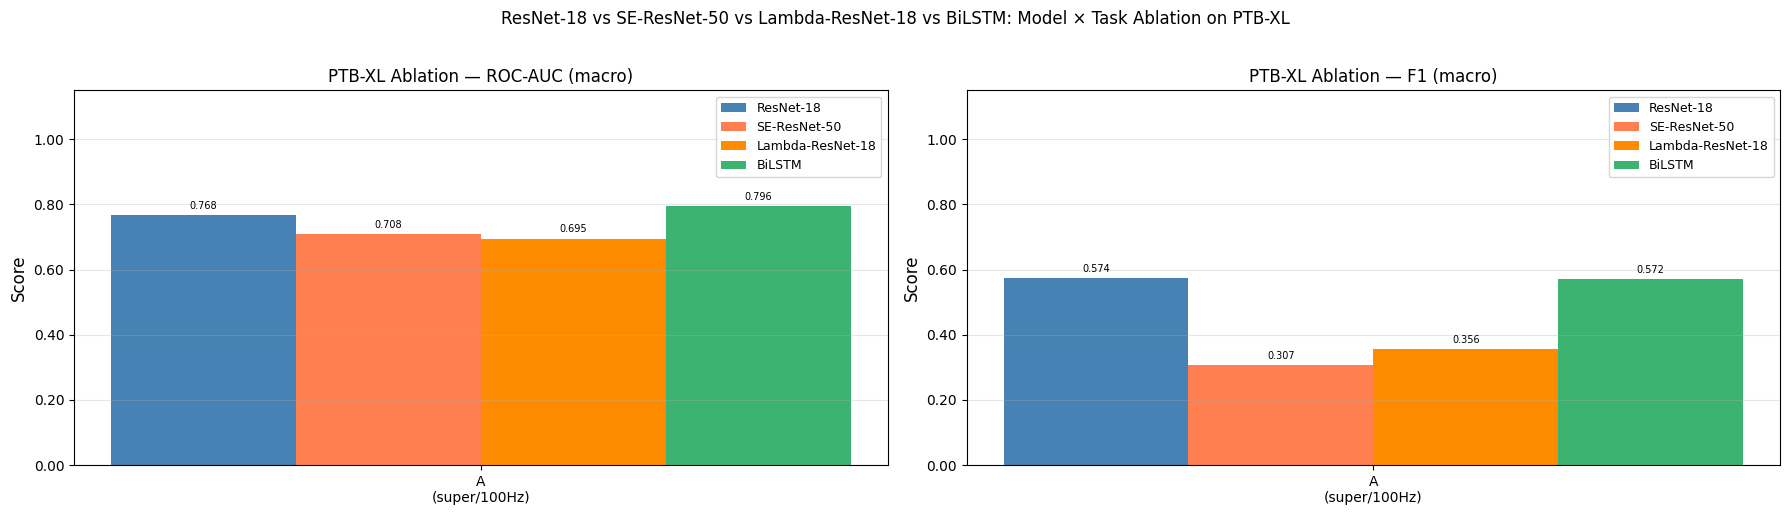

Figure saved to ptbxl_model_comparison_ablation.png


In [11]:
_label_map = {
    'A — superdiagnostic / 100 Hz (baseline)': 'A\n(super/100Hz)',
    'B — superdiagnostic / 500 Hz':            'B\n(super/500Hz)',
    'C — diagnostic (27-class) / 100 Hz':      'C\n(diag/100Hz)',
    'D — diagnostic (27-class) / 500 Hz':      'D\n(diag/500Hz)',
}
configs      = [c['name'] for c in ABLATION_CONFIGS]
short_labels = [_label_map[c] for c in configs]
model_names  = [m['name'] for m in MODELS]
colors       = ['steelblue', 'coral', 'darkorange', 'mediumseagreen']

x        = np.arange(len(short_labels))
n_models = len(model_names)
width    = 0.18
offsets  = np.linspace(-(n_models - 1) * width / 2,
                        (n_models - 1) * width / 2,
                        n_models)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax_idx, (metric, metric_label) in enumerate([
    ('roc_auc_macro', 'ROC-AUC (macro)'),
    ('f1_macro',      'F1 (macro)'),
]):
    ax = axes[ax_idx]
    for m_idx, mname in enumerate(model_names):
        vals = [
            results_df[
                (results_df['model'] == mname) &
                (results_df['config'] == cfg)
            ][metric].values[0]
            for cfg in configs
        ]
        bars = ax.bar(x + offsets[m_idx], vals, width,
                      label=mname, color=colors[m_idx])
        ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(f'PTB-XL Ablation — {metric_label}', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('ResNet-18 vs SE-ResNet-50 vs Lambda-ResNet-18 vs BiLSTM: Model × Task Ablation on PTB-XL',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('ptbxl_model_comparison_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to ptbxl_model_comparison_ablation.png')


## 9. Analysis & Findings

### Effect of Label Granularity

Comparing configs **A vs C** (both at 100 Hz): moving from the 5-class
**superdiagnostic** vocabulary to the 27-class **diagnostic** vocabulary
increases classification difficulty because:

* Rare classes have far fewer positive examples, making gradient updates noisy.
* The larger output head must learn $K = 27$ independent sigmoid thresholds.
* Macro averaging penalises poor performance on rare labels equally.

Formally, the expected macro-AUC satisfies
$$\overline{\text{AUC}}_{27} \leq \overline{\text{AUC}}_{5}$$
when the 27-class problem is strictly harder per class.

### Effect of Sampling Rate

Comparing configs **A vs B** (both superdiagnostic): at 500 Hz ($T = 5000$)
the model receives 5× more temporal resolution per lead.  This allows the
model to detect high-frequency features (notches, fragmented QRS) that are
aliased away at 100 Hz.  However:

* Input size grows by 5×, substantially increasing memory and training time.
* SE-ResNet-50's strided convolutions progressively downsample, scaling the
  effective receptive field with $T$; BiLSTM processes all time-steps sequentially
  so benefits more directly from longer inputs.

### Effect of Model Architecture

Comparing all four architectures across the same configs:

* **ResNet-18** (control) — a plain 1-D residual network without attention.
  Provides the baseline CNN performance against which attention-augmented
  variants are measured.

* **SE-ResNet-50** — augments bottleneck blocks with Squeeze-Excitation
  channel attention:
  $$\tilde{x}_c = \sigma\!\left(W_2\,\delta\!\left(W_1\,z_c\right)\right) \cdot x_c$$
  where $z_c$ is the global average-pooled channel descriptor and $\delta$ is ReLU.
  Expected to outperform ResNet-18 by recalibrating channel responses to
  emphasise diagnostically relevant waveform features.

* **Lambda-ResNet-18** — replaces SE modules with Lambda layers that compute
  both *content-based* and *position-based* linear attention without explicit
  softmax:
  $$\lambda_n = \sum_m \text{softmax}(k_m) \cdot (v_m \odot e_{n-m})$$
  This captures long-range context more efficiently than convolution while
  remaining computationally lighter than full self-attention.

* **BiLSTM** — a single bidirectional LSTM layer with $H = 64$ hidden units
  ($\text{lstm\_d1\_h64}$ from Nonaka & Seita 2021), processing the full sequence
  left-to-right and right-to-left and taking the last hidden state:
  $$h_T = [\overrightarrow{h}_T ; \overleftarrow{h}_1] \in \mathbb{R}^{2H}$$
  Captures long-range temporal dependencies but may under-perform CNN variants
  on localised morphological patterns.

### Trade-off Summary

| Factor | Expected ranking |
|--------|----------------|
| Fewer classes (5 vs 27) | All models easier; relative ranking preserved |
| Higher sampling rate (500 Hz) | All models improve; BiLSTM benefits proportionally more |
| Architecture (no attention) | ResNet-18 < SE-ResNet-50 ≈ Lambda-ResNet-18 |
| Architecture (CNN vs RNN) | CNN variants expected to outperform BiLSTM on morphological tasks |

These findings closely mirror the comprehensive benchmarks in Strodthoff *et al.*
(2021) and Nonaka & Seita (2021), where CNN-based models (and attention-augmented
variants) generally outperform RNN baselines on PTB-XL when trained sufficiently long.

## 10. References

1. Wagner, P. *et al.* (2020). PTB-XL, a large publicly available electrocardiography dataset.
   *Scientific Data* 7, 154. https://doi.org/10.1038/s41597-020-0495-6

2. Reyna, M.A. *et al.* (2020). Will Two Do? Varying Dimensions in Electrocardiography:
   The PhysioNet/Computing in Cardiology Challenge 2020. *CinC 2020*.

3. Strodthoff, N. *et al.* (2021). Deep Learning for ECG Analysis: Benchmarks and Insights
   from PTB-XL. *IEEE JBHI* 25, 1519–1528.

4. Nonaka, N. & Seita, J. (2021). In-depth Benchmarking of Deep Neural Network Architectures
   for ECG Diagnosis. *Machine Learning for Healthcare (MLHC) 2021*.

5. Hu, J. *et al.* (2018). Squeeze-and-Excitation Networks. *CVPR 2018*.

6. Zhao, M. *et al.* (2024). PyHealth: A Deep Learning Toolkit for Healthcare Predictive
   Modeling. *arXiv:2401.06284*.